# Synthetic data validation

Runs every check in `docs/synthetic_data.md` → *Validation checks* on the full run in
`data/output/`, then plots one normal day per machine type, each anomaly type and one
failure drift. Run `python data/generator/generate.py` first.

The last cell is a pass/fail table; it raises if any check fails.
Ground truth (`anomaly_label`, `anomaly_type`, `data/output/truth/`) is used here for
**evaluation only**, never as a model feature.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
GEN = ROOT / "data" / "generator"
OUT = ROOT / "data" / "output"
sys.path.insert(0, str(GEN))
from common import SCHEMA, SKIP_COLUMNS  # noqa: E402
from tasks import BASE_RATE, F_MATERIAL  # noqa: E402

cfg = yaml.safe_load((GEN / "config.yaml").read_text(encoding="utf-8"))

TS_COLS = {"ts", "start_time", "end_time", "event_date", "scheduled_start", "actual_start",
           "actual_end", "started_at", "completed_at", "failure_ts", "repair_ts",
           "start_ts", "end_ts"}

def load_csv(path):
    df = pd.read_csv(path, low_memory=False)
    for c in TS_COLS & set(df.columns):
        df[c] = pd.to_datetime(df[c], utc=True, format="ISO8601")
    return df

names = ["sites", "operators", "machines", "shifts", "weather", "tasks", "maintenance_log",
         "safety_events", "fatigue_log", "incidents", "training_modules", "training_records"]
T = {n: load_csv(OUT / f"{n}.csv") for n in names}
T["telemetry"] = pd.read_parquet(OUT / "telemetry.parquet")
events = load_csv(OUT / "truth" / "anomaly_events.csv")
events["details"] = events.details.map(json.loads)
failures = load_csv(OUT / "truth" / "failures.csv")
tel = T["telemetry"]

results = []  # (check, value, target, passed)
def check(name, value, target, passed):
    results.append({"check": name, "value": value, "target": target, "pass": bool(passed)})
    print(f"{'PASS' if passed else 'FAIL'}  {name}: {value}  (target {target})")

{n: len(df) for n, df in T.items()}

{'sites': 2,
 'operators': 20,
 'machines': 12,
 'shifts': 1448,
 'weather': 4368,
 'tasks': 7213,
 'maintenance_log': 83,
 'safety_events': 3798,
 'fatigue_log': 652228,
 'incidents': 45,
 'training_modules': 10,
 'training_records': 36,
 'telemetry': 652228}

## Palette

Categorical slots from the validated default palette (dataviz skill, light surface), assigned in
fixed order. Anomaly and failure spans are shaded in a neutral grey and always carry a text
label, so meaning never depends on colour alone.

In [2]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK_2, GRID, SURFACE, SPAN = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb", "#d9d8d3"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.4,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 1. Row counts match config

In [3]:
n_machines = sum(cfg["machines"].values()) * len(cfg["sites"])
days = cfg["days"]
check("sites", len(T["sites"]), len(cfg["sites"]), len(T["sites"]) == len(cfg["sites"]))
check("machines", len(T["machines"]), n_machines, len(T["machines"]) == n_machines)
check("operators", len(T["operators"]), cfg["operators"], len(T["operators"]) == cfg["operators"])
wx = len(cfg["sites"]) * (days + 1) * 24
check("weather rows (hourly, +1 day for night shifts)", len(T["weather"]), wx, len(T["weather"]) == wx)

sh = T["shifts"]
n_dates = sh.shift_date.nunique()
check("shift dates cover the run", n_dates, days, n_dates == days)
per_machine_days = sh[sh.shift_type == "day"].groupby("machine_id").shift_date.nunique()
spread = int(per_machine_days.max() - per_machine_days.min())
check("day shifts per machine (breakdowns, operator shortage)",
      f"{per_machine_days.min()}-{per_machine_days.max()}",
      f"min >= 85% of {days}, spread <= 12 (no machine left out systematically)",
      per_machine_days.min() >= 0.85 * days and spread <= 12)
night_share = (sh.shift_type == "night").mean()
check("night shift share", round(night_share, 3), "0.20-0.35 (capped by operators)",
      0.20 <= night_share <= 0.35)
tps = T["tasks"].groupby("shift_id").size()
lo, hi = cfg["tasks_per_shift"]
check("tasks per shift", f"{tps.min()}-{tps.max()}", f"{lo}-{hi}", tps.between(lo, hi).all())

shift_min = ((sh.end_time - sh.start_time).dt.total_seconds() / 60).sum()
check("telemetry rows vs shift minutes", f"{len(tel):,} / {shift_min:,.0f}",
      "80-100% (engine off after early finish)", 0.8 <= len(tel) / shift_min <= 1.0)
dup = tel.duplicated(["machine_id", "ts"]).sum()
check("telemetry (machine_id, ts) unique", int(dup), 0, dup == 0)

PASS  sites: 2  (target 2)
PASS  machines: 12  (target 12)
PASS  operators: 20  (target 20)
PASS  weather rows (hourly, +1 day for night shifts): 4368  (target 4368)
PASS  shift dates cover the run: 90  (target 90)
PASS  day shifts per machine (breakdowns, operator shortage): 79-88  (target min >= 85% of 90, spread <= 12 (no machine left out systematically))
PASS  night shift share: 0.298  (target 0.20-0.35 (capped by operators))
PASS  tasks per shift: 4-6  (target 4-6)
PASS  telemetry rows vs shift minutes: 652,228 / 695,040  (target 80-100% (engine off after early finish))
PASS  telemetry (machine_id, ts) unique: 0  (target 0)


## 2. No nulls in required columns, enums valid, foreign keys valid

In [4]:
bad_null = []
for name, df in T.items():
    for col in SCHEMA[name]:
        if col.name in SKIP_COLUMNS:
            continue
        if col.not_null and df[col.name].isna().any():
            bad_null.append(f"{name}.{col.name}")
check("NOT NULL columns without nulls", "none" if not bad_null else bad_null, "none", not bad_null)

FKS = [
    ("operators", "site_id", "sites", "site_id"), ("machines", "site_id", "sites", "site_id"),
    ("shifts", "site_id", "sites", "site_id"), ("shifts", "operator_id", "operators", "operator_id"),
    ("shifts", "machine_id", "machines", "machine_id"), ("weather", "site_id", "sites", "site_id"),
    ("tasks", "shift_id", "shifts", "shift_id"), ("tasks", "machine_id", "machines", "machine_id"),
    ("tasks", "operator_id", "operators", "operator_id"),
    ("maintenance_log", "machine_id", "machines", "machine_id"),
    ("telemetry", "machine_id", "machines", "machine_id"),
    ("telemetry", "operator_id", "operators", "operator_id"),
    ("telemetry", "shift_id", "shifts", "shift_id"),
    ("safety_events", "machine_id", "machines", "machine_id"),
    ("safety_events", "operator_id", "operators", "operator_id"),
    ("fatigue_log", "operator_id", "operators", "operator_id"),
    ("fatigue_log", "shift_id", "shifts", "shift_id"),
    ("incidents", "machine_id", "machines", "machine_id"),
    ("incidents", "linked_event_id", "safety_events", "id"),
    ("training_records", "operator_id", "operators", "operator_id"),
    ("training_records", "module_id", "training_modules", "module_id"),
]
bad_fk = []
for t, c, rt, rc in FKS:
    vals = T[t][c].dropna()
    if not vals.isin(T[rt][rc]).all():
        bad_fk.append(f"{t}.{c}")
check("foreign keys valid", "all" if not bad_fk else bad_fk, "all", not bad_fk)
for name in ["shifts", "tasks", "telemetry", "fatigue_log"]:
    key = {"shifts": "shift_id", "tasks": "task_id"}.get(name, "id")
    assert T[name][key].is_unique, name

PASS  NOT NULL columns without nulls: none  (target none)


PASS  foreign keys valid: all  (target all)


## 3. Correlations

The planner sizes each task's quantity to fill the shift from what it knows (base rate,
material, slope, operator skill). So raw duration mostly reflects the plan. The hidden factors
show up in **duration per unit of work**: `actual_duration_min / base_min`, where
`base_min = quantity / base_rate × 60`.

In [5]:
tasks = T["tasks"].merge(T["operators"][["operator_id", "skill_score", "personality"]])
tasks = tasks.merge(T["machines"][["machine_id", "machine_type"]])
tasks = tasks.merge(T["shifts"][["shift_id", "shift_type", "start_time"]])
done = tasks[tasks.status == "completed"].copy()
rate = [BASE_RATE[m][t] * (1000 / h if t == "haul" else 1)
        for m, t, h in zip(done.machine_type, done.task_type, done.haul_distance_m.fillna(0))]
done["base_min"] = done.quantity / np.array(rate) * 60
done["per_unit"] = done.actual_duration_min / done.base_min
done["hours_into"] = (done.actual_start - done.start_time).dt.total_seconds() / 3600
w = T["weather"].sort_values("ts")
done = pd.merge_asof(done.sort_values("actual_start"), w[["site_id", "ts", "rain_mm"]],
                     left_on="actual_start", right_on="ts", by="site_id", direction="backward")
done["night"] = (done.shift_type == "night").astype(int)

r_rain = done.per_unit.corr(done.rain_mm)
r_skill = done.per_unit.corr(done.skill_score)
check("corr(duration per unit, rain)", round(r_rain, 3), "> 0", r_rain > 0)
check("corr(duration per unit, skill)", round(r_skill, 3), "< 0", r_skill < 0)
print("raw corr(duration, rain) =", round(done.actual_duration_min.corr(done.rain_mm), 3),
      " raw corr(duration, skill) =", round(done.actual_duration_min.corr(done.skill_score), 3))

fat = T["fatigue_log"].merge(T["shifts"][["shift_id", "start_time", "shift_type"]])
fat["hours_into"] = (fat.ts - fat.start_time).dt.total_seconds() / 3600
r_perclos = fat.perclos_60s.corr(fat.hours_into)
check("corr(perclos, hours_into_shift)", round(r_perclos, 3), "> 0", r_perclos > 0)

PASS  corr(duration per unit, rain): 0.066  (target > 0)
PASS  corr(duration per unit, skill): -0.505  (target < 0)
raw corr(duration, rain) = 0.026  raw corr(duration, skill) = -0.051
PASS  corr(perclos, hours_into_shift): 0.753  (target > 0)


## 4. Anomalies, failures, incidents, personalities

In [6]:
injected = tel.anomaly_type.notna() & ~tel.anomaly_type.fillna("").str.startswith("pre_failure")
pre_fail = tel.anomaly_type.fillna("").str.startswith("pre_failure")
inj_rate = injected.mean()
check("injected anomaly rate (share of telemetry rows)", f"{inj_rate:.2%}", "2.5-3.5%",
      0.025 <= inj_rate <= 0.035)
print(f"pre_failure_* labelled rows: {pre_fail.mean():.2%}; any anomaly_label: {tel.anomaly_label.mean():.2%}")
missing = set(["overheating", "hydraulic_leak", "excessive_idle", "battery_fault", "sensor_glitch",
               "unsafe_operation"]) - set(tel.anomaly_type.dropna())
check("all six injected anomaly types present", "all" if not missing else missing, "all", not missing)
check("anomaly_label == (anomaly_type is not null)", "consistent", "consistent",
      (tel.anomaly_label == tel.anomaly_type.notna()).all())

n_fail = int((T["maintenance_log"].event_type == "failure").sum())
check("failures", n_fail, "20-30", 20 <= n_fail <= 30)
n_rep = int((T["maintenance_log"].event_type == "repair").sum())
check("one repair row per failure", n_rep, n_fail, n_rep == n_fail)
check("incidents", len(T["incidents"]), "> 0", len(T["incidents"]) > 0)

# Fault codes: none for glitches; ~50% of real faults carry one.
glitch_codes = tel.loc[tel.anomaly_type == "sensor_glitch", "fault_code"].notna().sum()
check("fault codes on sensor_glitch rows", int(glitch_codes), 0, glitch_codes == 0)
real = events[events.anomaly_type.isin(["overheating", "hydraulic_leak", "battery_fault"])
              | events.anomaly_type.str.startswith("pre_failure")]
coded = real.fault_code.notna().mean()
check("share of real faults with a fault code", f"{coded:.0%}", "40-60%", 0.4 <= coded <= 0.6)
behaviour_codes = events[events.anomaly_type.isin(["excessive_idle", "unsafe_operation"])].fault_code.notna().sum()
print("behaviour anomalies with a code:", behaviour_codes)

PASS  injected anomaly rate (share of telemetry rows): 3.00%  (target 2.5-3.5%)
pre_failure_* labelled rows: 5.69%; any anomaly_label: 8.69%
PASS  all six injected anomaly types present: all  (target all)
PASS  anomaly_label == (anomaly_type is not null): consistent  (target consistent)
PASS  failures: 25  (target 20-30)
PASS  one repair row per failure: 25  (target 25)
PASS  incidents: 45  (target > 0)
PASS  fault codes on sensor_glitch rows: 0  (target 0)
PASS  share of real faults with a fault code: 47%  (target 40-60%)
behaviour anomalies with a code: 0


In [7]:
# Non-overlap: injected events never overlap each other or a failure's labelled drift window,
# checked on the truth intervals per machine (end exclusive).
iv = events[["machine_id", "anomaly_type", "start_ts", "end_ts"]].sort_values(["machine_id", "start_ts"])
nxt = iv.groupby("machine_id").start_ts.shift(-1)
overlaps = int((nxt < iv.end_ts).sum())
check("overlapping anomaly / drift-label intervals", overlaps, 0, overlaps == 0)

# Row-level: no telemetry row carries two things, and injected runs never touch drift labels.
t = tel[["machine_id", "ts", "anomaly_type"]].sort_values(["machine_id", "ts"])
prev = t.groupby("machine_id").anomaly_type.shift(1)
same_m = t.machine_id.eq(t.machine_id.shift(1))
touch = same_m & t.anomaly_type.notna() & prev.notna() & (t.anomaly_type != prev)
check("adjacent rows with two different anomaly types", int(touch.sum()), 0, touch.sum() == 0)

PASS  overlapping anomaly / drift-label intervals: 0  (target 0)


PASS  adjacent rows with two different anomaly types: 0  (target 0)


In [8]:
ops = T["operators"]
idle = (tel.merge(ops[["operator_id", "personality"]])
        .groupby(["personality", "operator_id"]).is_idle.mean().rename("idle_pct") * 100)
by_p = idle.groupby("personality").agg(["mean", "min", "max", "count"]).sort_values("mean")
display(by_p.round(1))
present = set(ops.personality) == {"efficient", "average", "idler", "aggressive", "novice"}
check("every personality present", sorted(set(ops.personality)), "all 5", present)
gaps = np.diff(by_p["mean"].to_numpy())
no_overlap = (by_p["min"].to_numpy()[1:] > by_p["max"].to_numpy()[:-1]).all()
check("personality idle_pct distinct (mean gap, operator ranges)",
      f"min gap {gaps.min():.1f} pp, ranges overlap: {not no_overlap}",
      ">= 2 pp and no overlap", gaps.min() >= 2 and no_overlap)

,mean,min,max,count
personality,,,,
efficient,8.7,8.5,9.3,5
aggressive,11.6,10.8,12.3,2
average,15.9,15.6,16.5,8
novice,22.5,22.2,22.7,2
idler,35.1,34.3,35.6,3


PASS  every personality present: ['aggressive', 'average', 'efficient', 'idler', 'novice']  (target all 5)
PASS  personality idle_pct distinct (mean gap, operator ranges): min gap 2.8 pp, ranges overlap: False  (target >= 2 pp and no overlap)


## 5. Baseline: linear model on tasks

Plain `LinearRegression` on `log(actual_duration_min)` from columns a real planner has:
log base minutes, material, slope, rain at start, night, hours into the shift, machine
type, operator skill, and the operator (one-hot, which stands in for the hidden
personality). R² is reported on a 25% held-out set, back in minutes.

In [9]:
X = pd.get_dummies(
    done[["material_type", "machine_type", "operator_id"]].astype(str), drop_first=True
).astype(float)
X["log_base_min"] = np.log(done.base_min)
X["slope"] = done.terrain_slope_deg
X["rain"] = done.rain_mm.clip(upper=20)
X["night"] = done.night
X["late"] = (done.hours_into - 6).clip(lower=0)
X["skill"] = done.skill_score
y = np.log(done.actual_duration_min)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
lm = LinearRegression().fit(Xtr, ytr)
r2 = r2_score(np.exp(yte), np.exp(lm.predict(Xte)))
r2_log = r2_score(yte, lm.predict(Xte))
check("linear model R² on held-out tasks (minutes)", round(r2, 3), "> 0.6", r2 > 0.6)
print("R² in log space:", round(r2_log, 3), " completed tasks:", len(done))

PASS  linear model R² on held-out tasks (minutes): 0.909  (target > 0.6)
R² in log space: 0.939  completed tasks: 6379


## 6. Plots — one normal day per machine type

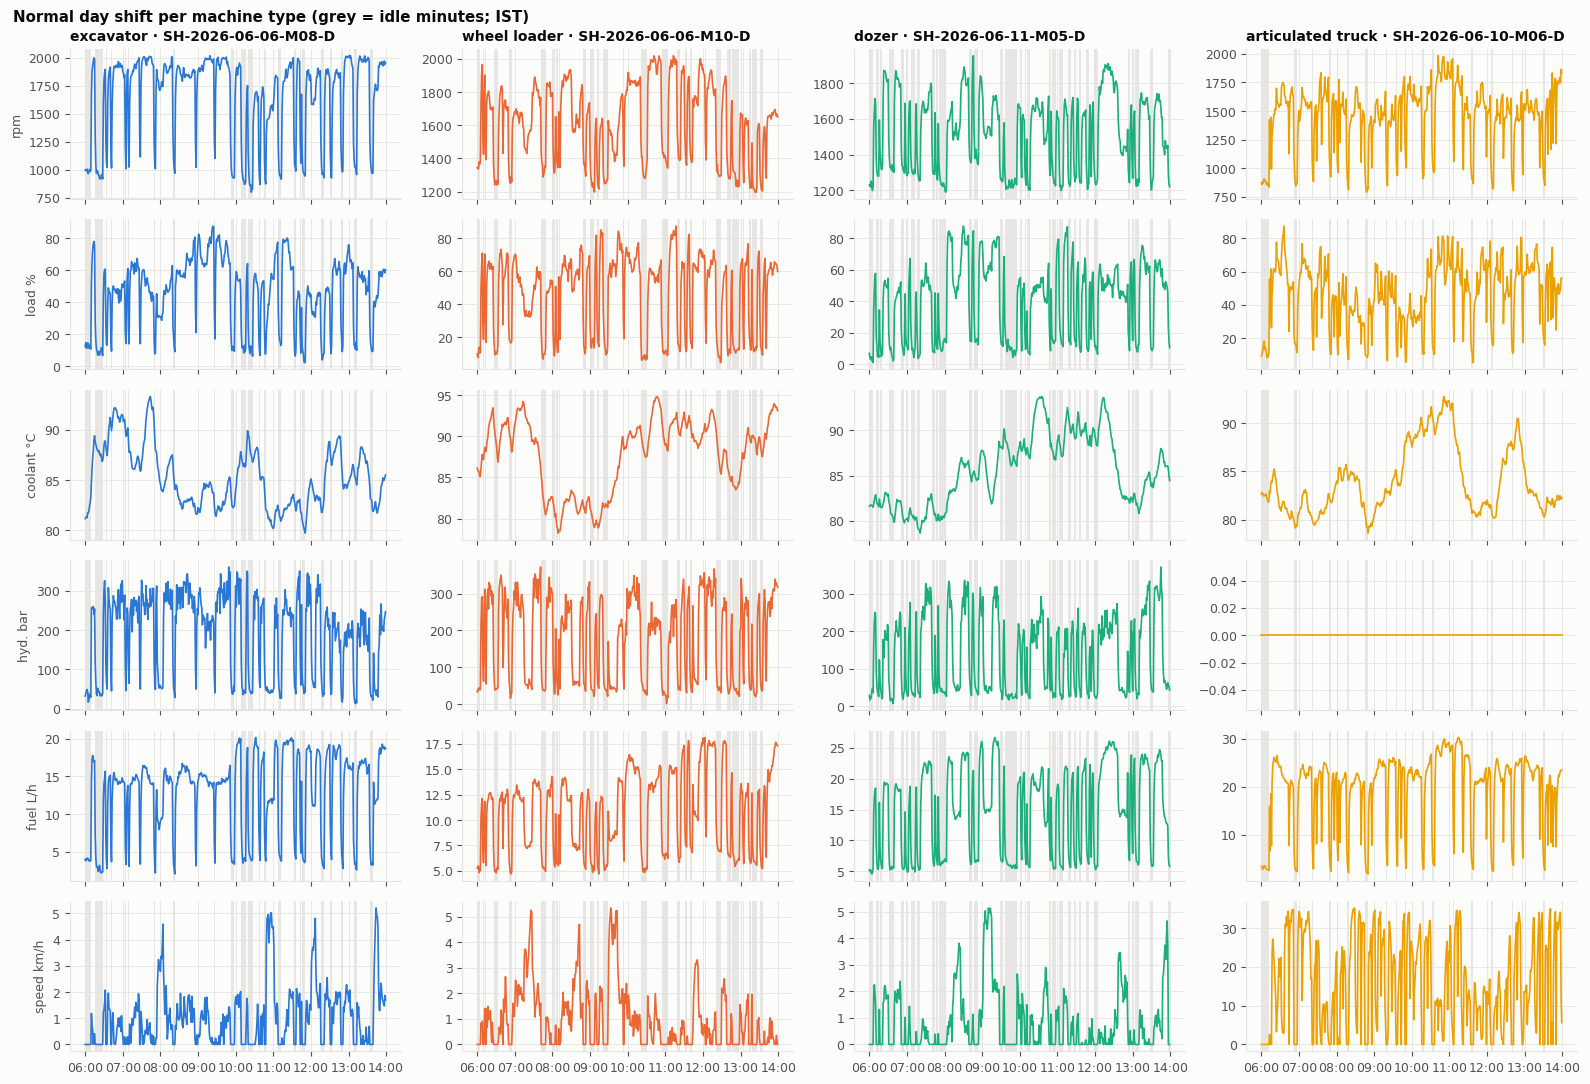

In [10]:
mach = T["machines"].set_index("machine_id")
anom_shifts = set(tel.loc[tel.anomaly_label, "shift_id"])
day_shifts = sh[(sh.shift_type == "day") & ~sh.shift_id.isin(anom_shifts)]
day_shifts = day_shifts.assign(machine_type=day_shifts.machine_id.map(mach.machine_type))
PANELS = [("engine_rpm", "rpm"), ("engine_load_pct", "load %"), ("coolant_temp_c", "coolant °C"),
          ("hydraulic_pressure_bar", "hyd. bar"), ("fuel_rate_lph", "fuel L/h"),
          ("ground_speed_kmh", "speed km/h")]
types = ["excavator", "wheel_loader", "dozer", "articulated_truck"]
fig, axes = plt.subplots(len(PANELS), 4, figsize=(16, 11), sharex="col")
for j, mt in enumerate(types):
    sid = day_shifts[day_shifts.machine_type == mt].shift_id.iloc[10]
    d = tel[tel.shift_id == sid].copy()
    d["local"] = d.ts.dt.tz_convert("Asia/Kolkata")
    axes[0, j].set_title(f"{mt.replace('_', ' ')} · {sid}")
    for i, (sig, lab) in enumerate(PANELS):
        ax = axes[i, j]
        ax.plot(d.local, d[sig], color=SERIES[j], lw=1.2)
        idle_runs = d.is_idle.to_numpy()
        ax.fill_between(d.local, 0, 1, where=idle_runs, transform=ax.get_xaxis_transform(),
                        color=SPAN, alpha=0.6, lw=0)
        if j == 0:
            ax.set_ylabel(lab)
    axes[-1, j].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M", tz="Asia/Kolkata"))
fig.suptitle("Normal day shift per machine type (grey = idle minutes; IST)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

## 7. Plots — each anomaly type

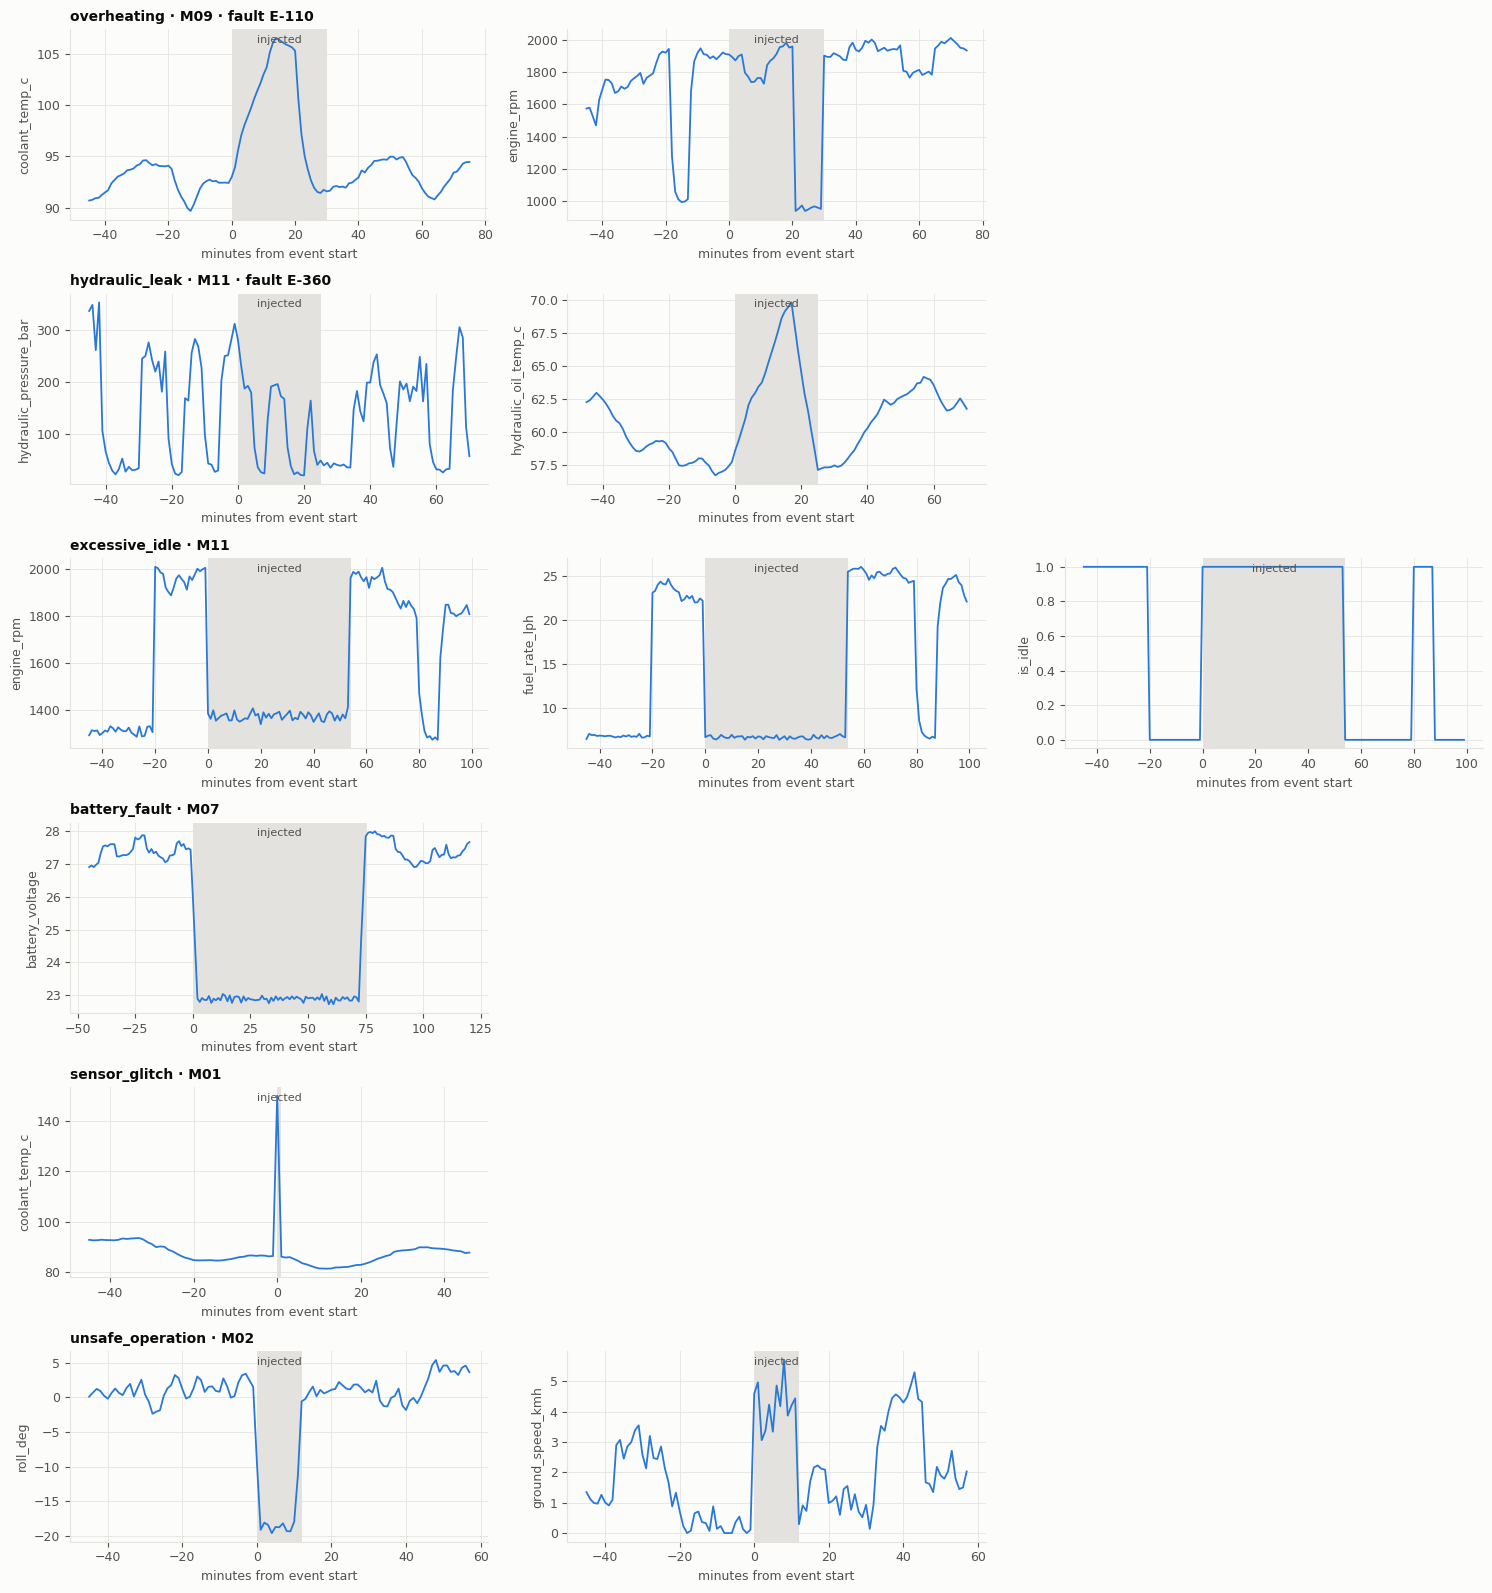

In [11]:
# One axis per signal (never two scales on one axis); grey span = injected minutes.
SHOW = {
    "overheating": ["coolant_temp_c", "engine_rpm"],
    "hydraulic_leak": ["hydraulic_pressure_bar", "hydraulic_oil_temp_c"],
    "excessive_idle": ["engine_rpm", "fuel_rate_lph", "is_idle"],
    "battery_fault": ["battery_voltage"],
    "sensor_glitch": ["coolant_temp_c"],
    "unsafe_operation": ["roll_deg", "ground_speed_kmh"],
}
fig, axes = plt.subplots(len(SHOW), 3, figsize=(15, 16))
for row, (atype, sigs) in zip(axes, SHOW.items()):
    cand = events[events.anomaly_type == atype]
    if atype == "sensor_glitch":
        cand = cand[cand.details.map(lambda d: d["signal"] == "coolant_temp_c")]
    if atype == "unsafe_operation":
        cand = cand[cand.details.map(lambda d: d["variant"] == "tilt" and d["axis"] == "roll_deg")]
    ev = cand.iloc[len(cand) // 2]
    win = tel[(tel.machine_id == ev.machine_id)
              & tel.ts.between(ev.start_ts - pd.Timedelta(minutes=45), ev.end_ts + pd.Timedelta(minutes=45))]
    x = (win.ts - ev.start_ts).dt.total_seconds() / 60
    code_txt = f" · fault {ev.fault_code}" if isinstance(ev.fault_code, str) else ""
    for k, ax in enumerate(row):
        if k >= len(sigs):
            ax.set_visible(False)
            continue
        ax.plot(x, win[sigs[k]].astype(float), color=SERIES[0], lw=1.3)
        ax.axvspan(0, ev.duration_min, color=SPAN, alpha=0.7, lw=0)
        ax.set_title(f"{atype} · {ev.machine_id}{code_txt}" if k == 0 else "", loc="left")
        ax.set_ylabel(sigs[k])
        ax.set_xlabel("minutes from event start")
        ax.text(ev.duration_min / 2, 0.97, "injected", transform=ax.get_xaxis_transform(),
                ha="center", va="top", color=INK_2, fontsize=8)
fig.tight_layout()

## 8. Plot — one failure drift

The hydraulics failure with the longest drift window: hourly means of the drifting signal
against engine hours to failure. The drift is quadratic in progress `p`; the last 20% of
the window is labelled `pre_failure_hydraulics`.

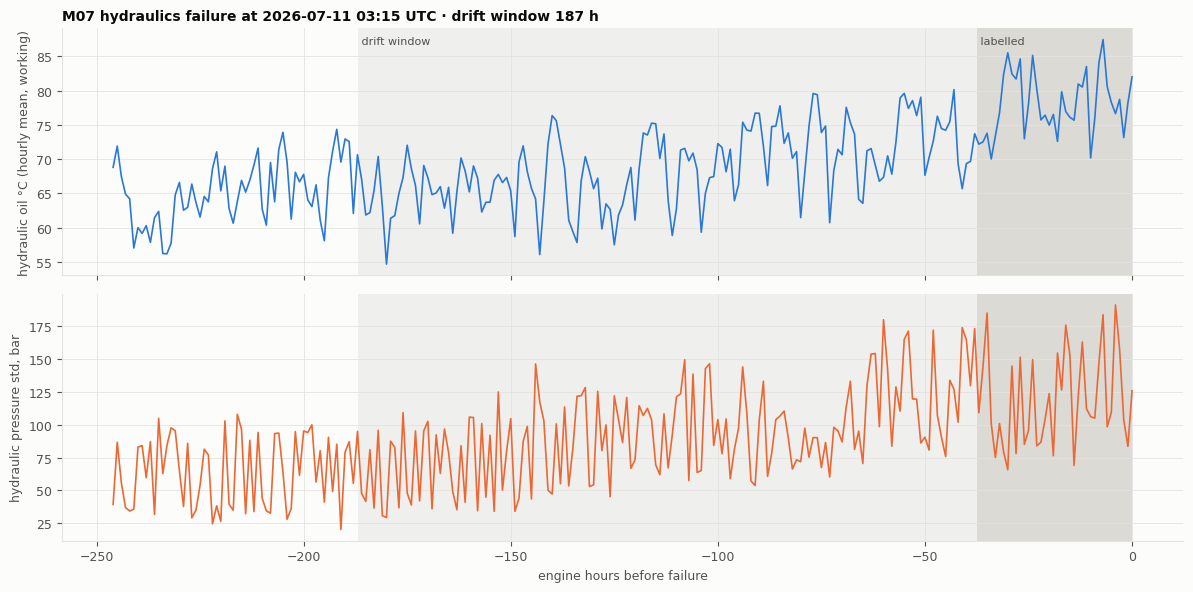

In [12]:
f = failures[failures.component == "hydraulics"].sort_values("drift_window_h").iloc[-1]
m_tel = tel[tel.machine_id == f.machine_id].copy()
lead = f.drift_window_h + 60
# engine hours to failure = cumulative engine-on minutes, counted back from the failure
m_tel = m_tel[m_tel.ts <= f.failure_ts].sort_values("ts")
m_tel["h_to_fail"] = (len(m_tel) - np.arange(len(m_tel))) / 60
m_tel = m_tel[m_tel.h_to_fail <= lead]
m_tel["hour"] = np.floor(m_tel.h_to_fail)
work = m_tel[~m_tel.is_idle]
hourly = work.groupby("hour").agg(oil=("hydraulic_oil_temp_c", "mean"),
                                  p_std=("hydraulic_pressure_bar", "std"))
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, col, lab, c in [(axes[0], "oil", "hydraulic oil °C (hourly mean, working)", SERIES[0]),
                        (axes[1], "p_std", "hydraulic pressure std, bar", SERIES[1])]:
    ax.plot(-hourly.index, hourly[col], color=c, lw=1.2)
    ax.axvspan(-f.drift_window_h, 0, color=SPAN, alpha=0.35, lw=0)
    ax.axvspan(-0.2 * f.drift_window_h, 0, color=SPAN, alpha=0.9, lw=0)
    ax.set_ylabel(lab)
axes[0].text(-f.drift_window_h, 0.97, " drift window", transform=axes[0].get_xaxis_transform(),
             va="top", color=INK_2, fontsize=8)
axes[0].text(-0.2 * f.drift_window_h, 0.97, " labelled", transform=axes[0].get_xaxis_transform(),
             va="top", color=INK_2, fontsize=8)
axes[1].set_xlabel("engine hours before failure")
axes[0].set_title(f"{f.machine_id} hydraulics failure at {f.failure_ts:%Y-%m-%d %H:%M} UTC · "
                  f"drift window {f.drift_window_h:.0f} h")
fig.tight_layout()

## Summary

In [13]:
summary = pd.DataFrame(results)
summary["pass"] = summary["pass"].map({True: "✔ pass", False: "✘ FAIL"})
display(summary)
failed = [r["check"] for r in results if not r["pass"]]
assert not failed, f"Failed checks: {failed}"
print(f"All {len(results)} checks pass.")

,check,value,target,pass
0,sites,2,2,✔ pass
1,machines,12,12,✔ pass
2,operators,20,20,✔ pass
3,"weather rows (hourly, +1 day for night shifts)",4368,4368,✔ pass
4,shift dates cover the run,90,90,✔ pass
5,"day shifts per machine (breakdowns, operator s...",79-88,"min >= 85% of 90, spread <= 12 (no machine lef...",✔ pass
6,night shift share,0.298,0.20-0.35 (capped by operators),✔ pass
7,tasks per shift,4-6,4-6,✔ pass
8,telemetry rows vs shift minutes,"652,228 / 695,040",80-100% (engine off after early finish),✔ pass
9,"telemetry (machine_id, ts) unique",0,0,✔ pass


All 28 checks pass.
